# Phishing Text Classifier — XLM-RoBERTa

This notebook trains an **XLM-RoBERTa** (multilingual) model for **phishing vs benign** classification using webpage content.

**Input dataset**: `data/raw_from_datasetv1/` (normalized from `DatasetV1`).
Expected structure after extraction on Colab:

```
/content/data/raw_from_datasetv1/
  ├── html/        # *.html (đầy đủ raw HTML)
  ├── text/        # *.txt (text đã trích sẵn)
  └── index.csv    # mapping file_id -> label, html_present, ...
```

**Filename format** `{label}_{index}.{html|txt}` where:
- `0` = benign
- `1` = phishing

**Output reports**: training/validation curves, feature correlation heatmap, confusion matrix, ROC/PR curve, classification report (precision/recall/F1) and the model files saved on Google Drive.

## 1. Setup Colab environment and mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys

# Check GPU
!nvidia-smi || echo 'No GPU detected. Please enable GPU: Runtime > Change runtime type > GPU.'

# Install necessary libraries
!pip -q install --upgrade transformers accelerate datasets scikit-learn beautifulsoup4 lxml pandas matplotlib seaborn

print('\n>>> Setup completed.')

Mounted at /content/drive
Fri May  8 14:55:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------

## 2. Configure dataset & model output paths

In [2]:
import os, shutil
from pathlib import Path

DRIVE_BASE = Path('/content/drive/MyDrive/Project3_Datasets')
DATASET_ZIP = DRIVE_BASE / 'raw_from_datasetv1.zip'
DATASET_DIR_DRIVE = DRIVE_BASE / 'raw_from_datasetv1'

LOCAL_DATA_ROOT = Path('/content/data')
DATASET_LOCAL = LOCAL_DATA_ROOT / 'raw_from_datasetv1'

OUTPUT_MODEL_DIR = Path('/content/drive/MyDrive/Project3_Models/xlmr_phishing')
OUTPUT_REPORT_DIR = Path('/content/drive/MyDrive/Project3_Reports/xlmr_phishing')
OUTPUT_REPORT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_MODEL_DIR.mkdir(parents=True, exist_ok=True)

USE_ZIP = True  # set to False if you uploaded the entire folder to Drive

LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)

if USE_ZIP:
    assert DATASET_ZIP.exists(), f'Zip file not found at: {DATASET_ZIP}. Please upload it first.'
    if DATASET_LOCAL.exists():
        shutil.rmtree(DATASET_LOCAL)
    print(f'>>> Extracting {DATASET_ZIP} ...')
    !unzip -q -o "{DATASET_ZIP}" -d "{LOCAL_DATA_ROOT}"
else:
    assert DATASET_DIR_DRIVE.exists(), f'Folder not found at: {DATASET_DIR_DRIVE}.'
    if DATASET_LOCAL.exists():
        shutil.rmtree(DATASET_LOCAL)
    shutil.copytree(DATASET_DIR_DRIVE, DATASET_LOCAL)

for sub in ['html', 'text']:
    p = DATASET_LOCAL / sub
    n = len(list(p.glob('*'))) if p.exists() else 0
    print(f'  {p}: {n} files')
print('  index.csv:', (DATASET_LOCAL / 'index.csv').exists())

>>> Extracting /content/drive/MyDrive/Project3_Datasets/raw_from_datasetv1.zip ...
  /content/data/raw_from_datasetv1/html: 889 files
  /content/data/raw_from_datasetv1/text: 889 files
  index.csv: True


## 3. Load + clean data (HTML + text)

Each sample will generate 2 text fields:
- `text_extracted`: from `text/{file_id}.txt` (pre-collected by the pipeline).
- `text_from_html`: extracted from `html/{file_id}.html` using BeautifulSoup, including `<title>`, `<meta>`, anchor text, input placeholder/name, form action, and visible text — as these are strong signals for phishing.

Then they are combined into `text_combined = title + meta + form_signals + visible_text` and used as input for XLM-RoBERTa.

In [3]:
import re
import pandas as pd
from bs4 import BeautifulSoup

DATA_DIR = DATASET_LOCAL
INDEX_CSV = DATA_DIR / 'index.csv'
TEXT_DIR = DATA_DIR / 'text'
HTML_DIR = DATA_DIR / 'html'

MAX_HTML_BYTES = 2_000_000  # avoid reading overly large HTML files

def clean_whitespace(s: str) -> str:
    return re.sub(r'\s+', ' ', s).strip()

def extract_signals_from_html(html: str) -> dict:
    """Extract semantically rich signals from HTML for phishing detection."""
    soup = BeautifulSoup(html, 'lxml')
    for tag in soup(['script', 'style', 'noscript']):
        tag.extract()
    title = soup.title.string if soup.title and soup.title.string else ''
    metas = []
    for m in soup.find_all('meta'):
        name = m.get('name') or m.get('property') or ''
        content = m.get('content') or ''
        if content:
            metas.append(f'{name}={content}')
    anchors = [a.get_text(' ', strip=True) for a in soup.find_all('a')]
    inputs = []
    for inp in soup.find_all('input'):
        inputs.append('|'.join([
            f"type={inp.get('type','')}",
            f"name={inp.get('name','')}",
            f"placeholder={inp.get('placeholder','')}",
            f"id={inp.get('id','')}",
        ]))
    forms = []
    for f in soup.find_all('form'):
        forms.append(f"form_action={f.get('action','')} method={f.get('method','')}")
    visible = soup.get_text(' ', strip=True)
    return {
        'title': clean_whitespace(title or ''),
        'meta': clean_whitespace(' | '.join(metas)),
        'anchors': clean_whitespace(' '.join(anchors))[:5000],
        'inputs': clean_whitespace(' '.join(inputs)),
        'forms': clean_whitespace(' '.join(forms)),
        'visible': clean_whitespace(visible)[:20000],
    }

rows = []
missing_text = 0
missing_html = 0
for txt_path in sorted(TEXT_DIR.glob('*.txt')):
    fname = txt_path.stem  # e.g. '1_0'
    parts = fname.split('_')
    if len(parts) < 2 or not parts[0].isdigit():
        continue
    label = int(parts[0])
    file_id = fname
    try:
        text_extracted = txt_path.read_text(encoding='utf-8', errors='ignore').strip()
    except Exception:
        text_extracted = ''
    if not text_extracted:
        missing_text += 1
    html_path = HTML_DIR / f'{file_id}.html'
    signals = {'title': '', 'meta': '', 'anchors': '', 'inputs': '', 'forms': '', 'visible': ''}
    if html_path.exists():
        size = html_path.stat().st_size
        try:
            html_str = html_path.read_text(encoding='utf-8', errors='replace')[:MAX_HTML_BYTES]
            signals = extract_signals_from_html(html_str)
        except Exception:
            pass
    else:
        missing_html += 1
    text_combined = ' \n '.join([
        f"<title> {signals['title']}",
        f"<meta> {signals['meta']}",
        f"<forms> {signals['forms']}",
        f"<inputs> {signals['inputs']}",
        f"<anchors> {signals['anchors']}",
        f"<text> {signals['visible'] or text_extracted}",
    ])
    rows.append({
        'file_id': file_id,
        'label': label,
        'text_extracted': text_extracted,
        **signals,
        'text_combined': clean_whitespace(text_combined),
    })

df = pd.DataFrame(rows)
print('Total rows:', len(df))
print('Missing text files (empty content):', missing_text)
print('Missing html files:', missing_html)
print('Label distribution:')
print(df['label'].value_counts().rename({0: 'benign(0)', 1: 'phishing(1)'}))
df.head(2)

Total rows: 889
Missing text files (empty content): 1
Missing html files: 0
Label distribution:
label
phishing(1)    689
benign(0)      200
Name: count, dtype: int64


,file_id,label,text_extracted,title,meta,anchors,inputs,forms,visible,text_combined
0,0_0,0,"Your Free Avatar, Profile, and Link In Bio | G...","Your Free Avatar, Profile, and Link In Bio | G...",=text/html; charset=utf-8 | =en | description=...,Link in Bio Developers Support Log in Get Star...,type=radio|name=g-editor|placeholder=|id=g-edi...,form_action=# method=post,"Your Free Avatar, Profile, and Link In Bio | G...","<title> Your Free Avatar, Profile, and Link In..."
1,0_1,0,Themeisle - Built to Last WordPress Themes & P...,Themeisle - Built to Last WordPress Themes & P...,"viewport=width=device-width, initial-scale=1, ...",Skip to content Themes Neve Hestia Neve FSE Al...,type=search|name=s|placeholder=Search for them...,form_action=https://themeisle.com/ method=get ...,Themeisle - Built to Last WordPress Themes & P...,<title> Themeisle - Built to Last WordPress Th...


## 4. EDA: Label distribution, text length, feature correlation heatmap

The heatmap is plotted between **numeric features** extracted from HTML (number of forms, inputs, presence of password field, text length, presence of IP, @, etc.) — these traditional features remain very effective for phishing detection.

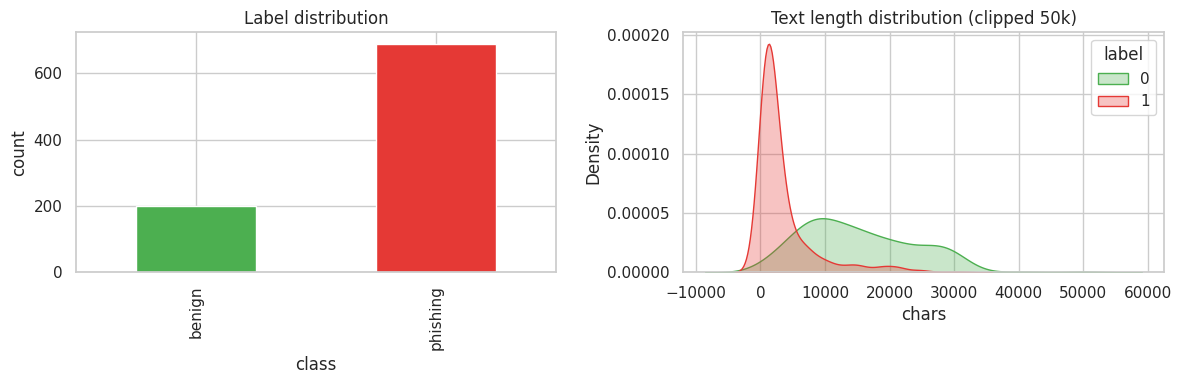

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook', style='whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['label'].value_counts().sort_index().rename({0: 'benign', 1: 'phishing'}).plot(kind='bar', ax=axes[0], color=['#4caf50', '#e53935'])
axes[0].set_title('Label distribution')
axes[0].set_xlabel('class')
axes[0].set_ylabel('count')
df['text_len'] = df['text_combined'].str.len()
for lab, color in [(0, '#4caf50'), (1, '#e53935')]:
    sns.kdeplot(df.loc[df.label == lab, 'text_len'].clip(upper=50000), ax=axes[1], label=str(lab), fill=True, alpha=0.3, color=color)
axes[1].set_title('Text length distribution (clipped 50k)')
axes[1].set_xlabel('chars')
axes[1].legend(title='label')
plt.tight_layout()
plt.savefig(OUTPUT_REPORT_DIR / 'eda_label_textlen.png', dpi=150)
plt.show()

/tmp/ipykernel_856/3319910941.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  'has_login_kw': df['text_combined'].str.contains(r'(login|sign in|signin|verify|password)', case=False, regex=True).astype(int),
/tmp/ipykernel_856/3319910941.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  'has_bank_kw': df['text_combined'].str.contains(r'(bank|paypal|secure|account|wallet)', case=False, regex=True).astype(int),


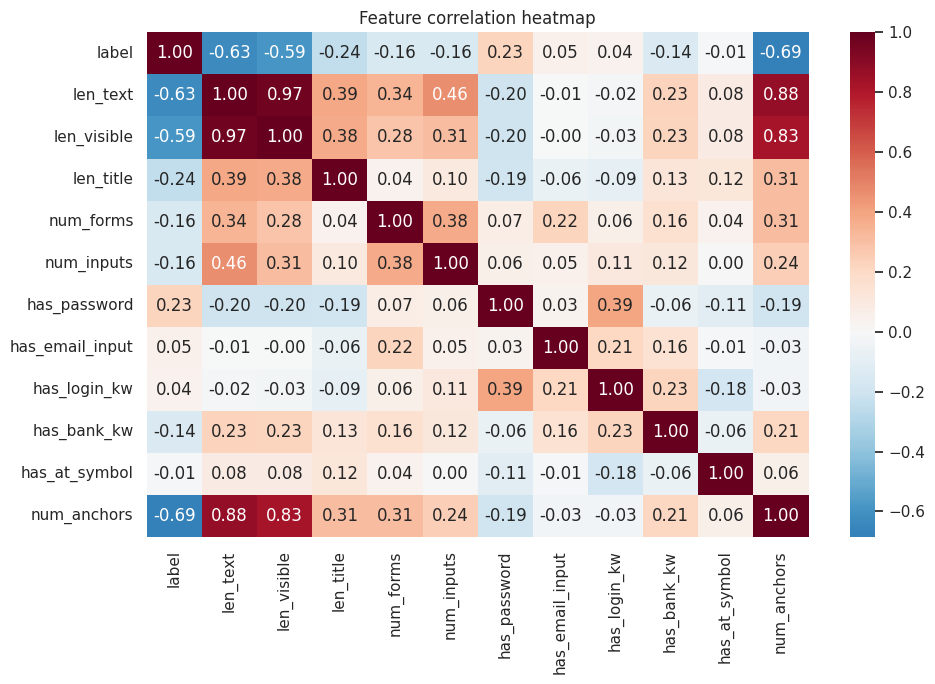

In [5]:
feat = pd.DataFrame({
    'label': df['label'],
    'len_text': df['text_combined'].str.len(),
    'len_visible': df['visible'].str.len(),
    'len_title': df['title'].str.len(),
    'num_forms': df['forms'].str.count('form_action='),
    'num_inputs': df['inputs'].str.count('type='),
    'has_password': df['inputs'].str.contains('type=password', case=False, regex=False).astype(int),
    'has_email_input': df['inputs'].str.contains('type=email', case=False, regex=False).astype(int),
    'has_login_kw': df['text_combined'].str.contains(r'(login|sign in|signin|verify|password)', case=False, regex=True).astype(int),
    'has_bank_kw': df['text_combined'].str.contains(r'(bank|paypal|secure|account|wallet)', case=False, regex=True).astype(int),
    'has_at_symbol': df['anchors'].str.contains('@', regex=False).astype(int),
    'num_anchors': df['anchors'].str.count(' '),
})

corr = feat.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Feature correlation heatmap')
plt.tight_layout()
plt.savefig(OUTPUT_REPORT_DIR / 'feature_correlation_heatmap.png', dpi=150)
plt.show()

## 5. Train/Val/Test split (stratified) and class imbalance handling
- **Stratified 70/15/15** split.
- Calculate `class_weights` for the loss function to reduce bias towards the majority phishing class.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

df = df[df['text_combined'].str.len() > 20].reset_index(drop=True)
print('Rows after empty filter:', len(df))

train_df, tmp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(tmp_df, test_size=0.50, random_state=42, stratify=tmp_df['label'])
print('train/val/test:', len(train_df), len(val_df), len(test_df))
print('train labels:', train_df['label'].value_counts().to_dict())
print('val labels:', val_df['label'].value_counts().to_dict())
print('test labels:', test_df['label'].value_counts().to_dict())

import numpy as np
class_weights_np = compute_class_weight('balanced', classes=np.array([0, 1]), y=train_df['label'].values)
print('class_weights:', class_weights_np)

Rows after empty filter: 889
train/val/test: 622 133 134
train labels: {1: 482, 0: 140}
val labels: {1: 103, 0: 30}
test labels: {1: 104, 0: 30}
class_weights: [2.22142857 0.64522822]


## 6. Tokenization with XLM-RoBERTa

Using `xlm-roberta-base` (multilingual). `max_length=256` balances speed and quality for webpage text after cleaning and prefixing with signal tags (`<title>`, `<forms>`, etc.).

In [7]:
import torch
from transformers import AutoTokenizer

MODEL_NAME = 'xlm-roberta-base'
MAX_LEN = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(texts):
    return tokenizer(list(texts), truncation=True, padding=True, max_length=MAX_LEN)

train_enc = tokenize(train_df['text_combined'])
val_enc = tokenize(val_df['text_combined'])
test_enc = tokenize(test_df['text_combined'])

class TextDataset(torch.utils.data.Dataset):
    def __init__(self, enc, labels):
        self.enc = enc
        self.labels = list(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
        item['labels'] = torch.tensor(int(self.labels[i]))
        return item

train_ds = TextDataset(train_enc, train_df['label'])
val_ds = TextDataset(val_enc, val_df['label'])
test_ds = TextDataset(test_enc, test_df['label'])
print('Tokenize OK. sizes:', len(train_ds), len(val_ds), len(test_ds))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenize OK. sizes: 622 133 134


## 7. Train XLM-RoBERTa with Trainer (weighted loss)

In [8]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

class_weights_t = torch.tensor(class_weights_np, dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_t.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall': recall_score(labels, preds, zero_division=0),
        'f1': f1_score(labels, preds, zero_division=0),
        'roc_auc': roc_auc_score(labels, probs) if len(set(labels)) > 1 else float('nan'),
    }

args = TrainingArguments(
    output_dir='/content/results_xlmr',
    num_train_epochs=4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_steps=20,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    report_to='none',
    fp16=torch.cuda.is_available(),
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

train_result = trainer.train()
print(train_result)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` inst

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.674759,0.569365,0.819549,0.811024,1.000000,0.895652,0.942395
2,0.312324,0.268096,0.939850,0.952381,0.970874,0.961538,0.970874
3,0.364746,0.293969,0.894737,1.000000,0.864078,0.927083,0.981877
4,0.269900,0.221411,0.962406,0.971154,0.980583,0.975845,0.991262


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=312, training_loss=0.4065890304553203, metrics={'train_runtime': 311.9985, 'train_samples_per_second': 7.974, 'train_steps_per_second': 1.0, 'total_flos': 327310152867840.0, 'train_loss': 0.4065890304553203, 'epoch': 4.0})


## 8. Training/Validation curves

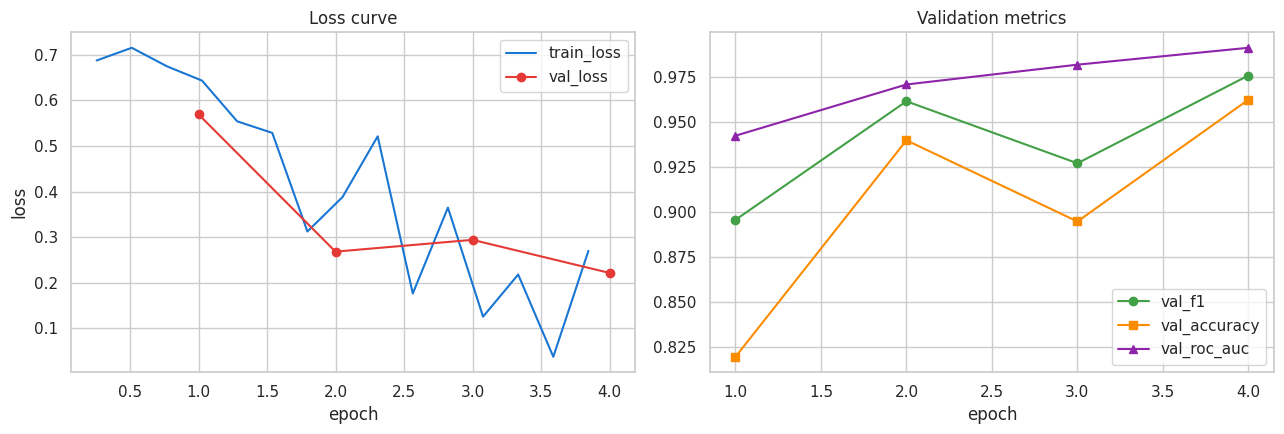

In [9]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
train_loss = [(h['epoch'], h['loss']) for h in history if 'loss' in h and 'eval_loss' not in h]
eval_rows = [(h['epoch'], h.get('eval_loss'), h.get('eval_f1'), h.get('eval_accuracy'), h.get('eval_roc_auc')) for h in history if 'eval_loss' in h]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
if train_loss:
    e, v = zip(*train_loss)
    axes[0].plot(e, v, label='train_loss', color='#1976d2')
if eval_rows:
    e, vl, *_ = zip(*eval_rows)
    axes[0].plot(e, vl, label='val_loss', color='#e53935', marker='o')
axes[0].set_title('Loss curve')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].legend()

if eval_rows:
    e, _, f1s, accs, aucs = zip(*eval_rows)
    axes[1].plot(e, f1s, label='val_f1', marker='o', color='#43a047')
    axes[1].plot(e, accs, label='val_accuracy', marker='s', color='#fb8c00')
    axes[1].plot(e, aucs, label='val_roc_auc', marker='^', color='#8e24aa')
    axes[1].set_title('Validation metrics')
    axes[1].set_xlabel('epoch')
    axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_REPORT_DIR / 'training_curves.png', dpi=150)
plt.show()

## 9. Evaluation on Test set + charts

Includes: Confusion matrix, ROC curve, Precision-Recall curve, classification report (precision/recall/F1).

Evaluating on Validation set to find optimal threshold for FPR <= 5%...


Optimized Threshold for FPR <= 5%: 0.9632 (Val FPR=0.0333, Val TPR=0.9515)


              precision    recall  f1-score   support

   benign(0)     0.7632    0.9667    0.8529        30
 phishing(1)     0.9896    0.9135    0.9500       104

    accuracy                         0.9254       134
   macro avg     0.8764    0.9401    0.9015       134
weighted avg     0.9389    0.9254    0.9283       134



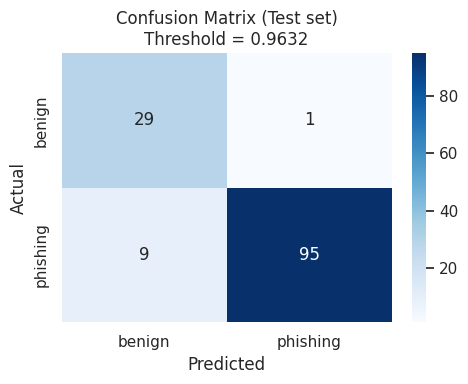

In [10]:
import numpy as np
import torch
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)
import matplotlib.pyplot as plt
import seaborn as sns

# -- NEW: Threshold optimization on Validation Set for FPR <= 5% --
print("Evaluating on Validation set to find optimal threshold for FPR <= 5%...")
val_preds_out = trainer.predict(val_ds)
val_labels = val_preds_out.label_ids
val_probs = torch.softmax(torch.tensor(val_preds_out.predictions), dim=-1).numpy()[:, 1]
fpr_val, tpr_val, thresholds_val = roc_curve(val_labels, val_probs)

target_fpr = 0.05
valid_indices = np.where(fpr_val <= target_fpr)[0]
best_idx = valid_indices[-1] if len(valid_indices) > 0 else 0
best_threshold = float(thresholds_val[best_idx])
print(f"Optimized Threshold for FPR <= 5%: {best_threshold:.4f} (Val FPR={fpr_val[best_idx]:.4f}, Val TPR={tpr_val[best_idx]:.4f})")

# -- Evaluation on Test set --
preds_out = trainer.predict(test_ds)
logits = preds_out.predictions
labels = preds_out.label_ids
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]

# Use optimized threshold instead of 0.5
preds = (probs >= best_threshold).astype(int)

report_text = classification_report(labels, preds, target_names=['benign(0)', 'phishing(1)'], digits=4)
print(report_text)
(OUTPUT_REPORT_DIR / 'classification_report.txt').write_text(report_text, encoding='utf-8')

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['benign', 'phishing'], yticklabels=['benign', 'phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Test set)\nThreshold = {best_threshold:.4f}')
plt.tight_layout()
plt.savefig(OUTPUT_REPORT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

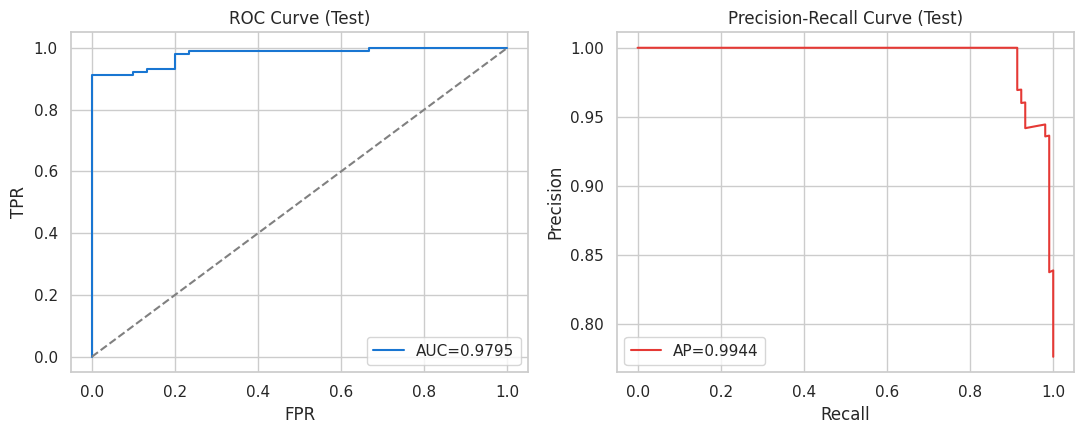

In [11]:
fpr, tpr, _ = roc_curve(labels, probs)
roc_auc = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(labels, probs)
ap = average_precision_score(labels, probs)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, tpr, label=f'AUC={roc_auc:.4f}', color='#1976d2')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_title('ROC Curve (Test)')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend()

axes[1].plot(rec, prec, label=f'AP={ap:.4f}', color='#e53935')
axes[1].set_title('Precision-Recall Curve (Test)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_REPORT_DIR / 'roc_pr_curves.png', dpi=150)
plt.show()

## 10. Save model + tokenizer + summary report

The model is saved to Drive at `Project3_Models/xlmr_phishing/`. You can load it back using `AutoModelForSequenceClassification.from_pretrained(...)` to use it in the extension/API.

In [14]:
import json

trainer.save_model(str(OUTPUT_MODEL_DIR))
tokenizer.save_pretrained(str(OUTPUT_MODEL_DIR))

summary = {
    'model_name': MODEL_NAME,
    'max_length': MAX_LEN,
    'epochs': args.num_train_epochs,
    'class_weights': class_weights_np.tolist(),
    'split_sizes': {'train': len(train_df), 'val': len(val_df), 'test': len(test_df)},
    'optimized_threshold': float(best_threshold),
    'test_metrics': {
        'accuracy': float((preds == labels).mean()),
        'roc_auc': float(roc_auc),
        'average_precision': float(ap),
    },
    'output_model_dir': str(OUTPUT_MODEL_DIR),
    'output_report_dir': str(OUTPUT_REPORT_DIR),
}
with (OUTPUT_REPORT_DIR / 'summary.json').open('w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
summary

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'model_name': 'xlm-roberta-base',
 'max_length': 256,
 'epochs': 4,
 'class_weights': [2.2214285714285715, 0.6452282157676349],
 'split_sizes': {'train': 622, 'val': 133, 'test': 134},
 'optimized_threshold': 0.963230550289154,
 'test_metrics': {'accuracy': 0.9253731343283582,
  'roc_auc': 0.9794871794871794,
  'average_precision': 0.9944483275959894},
 'output_model_dir': '/content/drive/MyDrive/Project3_Models/xlmr_phishing',
 'output_report_dir': '/content/drive/MyDrive/Project3_Reports/xlmr_phishing'}

## 11. (Optional) Test Inference

The cell below loads the model from Drive and predicts on 5 random test samples for a quick visual check.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tok = AutoTokenizer.from_pretrained(str(OUTPUT_MODEL_DIR))
mdl = AutoModelForSequenceClassification.from_pretrained(str(OUTPUT_MODEL_DIR)).to(device).eval()

samples = test_df.sample(min(5, len(test_df)), random_state=0)
with torch.no_grad():
    enc = tok(list(samples['text_combined']), truncation=True, padding=True, max_length=MAX_LEN, return_tensors='pt').to(device)
    logits = mdl(**enc).logits
    probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
for fid, lab, p in zip(samples['file_id'], samples['label'], probs):
    pred = int(p >= best_threshold)
    mark = '✅' if pred == lab else '❌'
    print(f'{mark} file_id={fid} true={lab} pred={pred} prob_phishing={p:.3f}')

## 12. (Optional) Hyperparameter Tuning with Optuna

This section demonstrates how to use Optuna for hyperparameter search. Since it trains multiple models, it takes a long time. You can enable it if needed.

In [ ]:
# !pip install optuna
# def model_init():
#     return AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
#
# hyper_trainer = WeightedTrainer(
#     model_init=model_init,
#     args=args,
#     train_dataset=train_ds,
#     eval_dataset=val_ds,
#     compute_metrics=compute_metrics,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
# )
#
# def optuna_hp_space(trial):
#     return {
#         "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
#         "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [8, 16]),
#         "weight_decay": trial.suggest_float("weight_decay", 0.01, 0.1)
#     }
#
# best_run = hyper_trainer.hyperparameter_search(
#     direction="maximize",
#     backend="optuna",
#     hp_space=optuna_hp_space,
#     n_trials=5
# )
# print('Best Run:', best_run)
